,nome,ano,classe,massa_gramas,massa_toneladas,tipo_registro,latitude,longitude,localizacao
16392,Hoba,1970.0,"Iron, IVB",60000000.0,60.0,Found,-19.58333,17.91667,"(-19.58333, 17.91667)"
5373,Cape York,1970.0,"Iron, IIIAB",58200000.0,58.2,Found,76.13333,-64.93333,"(76.13333, -64.93333)"
5365,Campo del Cielo,1970.0,"Iron, IAB-MG",50000000.0,50.0,Found,-27.46667,-60.58333,"(-27.46667, -60.58333)"
5370,Canyon Diablo,1970.0,"Iron, IAB-MG",30000000.0,30.0,Found,35.05000,-111.03333,"(35.05, -111.03333)"
3455,Armanty,1970.0,"Iron, IIIE",28000000.0,28.0,Found,47.00000,88.00000,"(47.0, 88.0)"
12613,Gibeon,1970.0,"Iron, IVA",26000000.0,26.0,Found,-25.50000,18.00000,"(-25.5, 18.0)"
5468,Chupaderos,1970.0,"Iron, IIIAB",24300000.0,24.3,Found,27.00000,-105.10000,"(27.0, -105.1)"
26297,Mundrabilla,1970.0,"Iron, IAB-ung",24000000.0,24.0,Found,-30.78333,127.55000,"(-30.78333, 127.55)"
920,Sikhote-Alin,1970.0,"Iron, IIAB",23000000.0,23.0,Fell,46.16000,134.65333,"(46.16, 134.65333)"
5016,Bacubirito,1970.0,"Iron, ungrouped",22000000.0,22.0,Found,26.20000,-107.83333,"(26.2, -107.83333)"


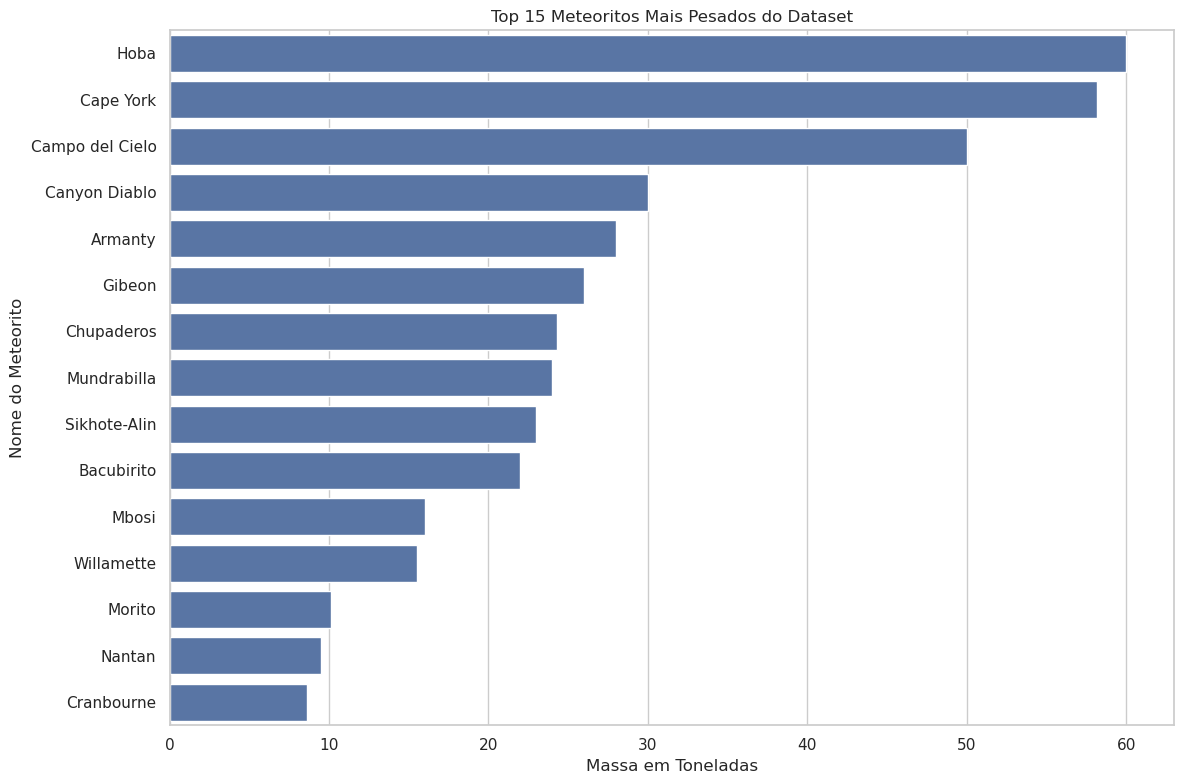

In [1]:
# Importa biblioteca principal para análise de dados
import pandas as pd

# Importa bibliotecas para criação de gráficos
import matplotlib.pyplot as plt
import seaborn as sns

# Importa biblioteca para exibir tabelas no Jupyter
from IPython.display import display

# Importa bibliotecas para limpar nomes das colunas
import re
import unicodedata

# Define o estilo visual dos gráficos
sns.set_theme(style="whitegrid")

# Faz o Pandas mostrar todas as colunas
pd.set_option("display.max_columns", None)

# Faz o Pandas mostrar até 100 linhas
pd.set_option("display.max_rows", 100)

# Link direto do dataset da NASA
url = "https://data.nasa.gov/docs/legacy/meteorite_landings/Meteorite_Landings.csv"

# Lê o dataset direto do link
df = pd.read_csv(url)

# Função para padronizar os nomes das colunas
def limpar_nome_coluna(nome):
    # Converte o nome da coluna para texto
    nome = str(nome)

    # Remove acentos, caso existam
    nome = unicodedata.normalize("NFKD", nome)
    nome = nome.encode("ascii", "ignore").decode("utf-8")

    # Converte para letras minúsculas
    nome = nome.lower()

    # Remove espaços no começo e no final
    nome = nome.strip()

    # Troca espaços e caracteres especiais por "_"
    nome = re.sub(r"[^a-z0-9]+", "_", nome)

    # Remove "_" do começo e do final
    nome = nome.strip("_")

    # Retorna o nome padronizado
    return nome

# Padroniza os nomes das colunas
df.columns = [limpar_nome_coluna(coluna) for coluna in df.columns]

# Converte a coluna mass_g para valor numérico
# Valores inválidos serão transformados em NaN
df["mass_g"] = pd.to_numeric(df["mass_g"], errors="coerce")

# Converte a coluna year para data
# Valores inválidos serão transformados em NaT
df["year"] = pd.to_datetime(df["year"], errors="coerce")

# Cria uma coluna apenas com o ano
df["ano"] = df["year"].dt.year

# Remove registros sem massa
df_limpo = df.dropna(subset=["mass_g"])

# Seleciona os 15 meteoritos mais pesados do dataset
top_15_meteoritos = (
    df_limpo
    .sort_values(by="mass_g", ascending=False)
    .head(15)
    .copy()
)

# Cria uma coluna com a massa em toneladas
# 1 tonelada = 1.000.000 gramas
top_15_meteoritos["massa_toneladas"] = top_15_meteoritos["mass_g"] / 1_000_000

# Cria uma tabela mais amigável para visualizar os dados
tabela_top_15 = top_15_meteoritos[[
    "name",
    "ano",
    "recclass",
    "mass_g",
    "massa_toneladas",
    "fall",
    "reclat",
    "reclong",
    "geolocation"
]].rename(columns={
    "name": "nome",
    "ano": "ano",
    "recclass": "classe",
    "mass_g": "massa_gramas",
    "massa_toneladas": "massa_toneladas",
    "fall": "tipo_registro",
    "reclat": "latitude",
    "reclong": "longitude",
    "geolocation": "localizacao"
})

# Mostra a tabela com os 15 meteoritos mais pesados
display(tabela_top_15)

# Cria o tamanho da figura do gráfico
plt.figure(figsize=(12, 8))

# Cria o gráfico de barras horizontal
sns.barplot(
    data=top_15_meteoritos,
    x="massa_toneladas",
    y="name"
)

# Adiciona título ao gráfico
plt.title("Top 15 Meteoritos Mais Pesados do Dataset")

# Adiciona nome ao eixo X
plt.xlabel("Massa em Toneladas")

# Adiciona nome ao eixo Y
plt.ylabel("Nome do Meteorito")

# Ajusta o layout para evitar cortes nos nomes
plt.tight_layout()

# Exibe o gráfico
plt.show()